# 베이스라인 모델 구현
## TF-IDF + Logistic Regression / Linear SVM

- 데이터: `data/processed/train_processed.csv`, `data/processed/valid_processed.csv`
- 입력 컬럼: `comments`
- 정답 컬럼: `label` (악성=1, 정상=0)
- 모델: TF-IDF 벡터화 + 로지스틱 회귀, 선형 SVM

In [2]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 불러오기
train_df = pd.read_csv("../data/processed/train_processed.csv")
valid_df = pd.read_csv("../data/processed/valid_processed.csv")

print("train shape:", train_df.shape)
print("valid shape:", valid_df.shape)
print(train_df.head())

train shape: (6693, 3)
valid shape: (1674, 3)
                                            comments       hate  label
0                                       야는 슴이 약한게 흠.  offensive      1
1  ...못된 넘들...남의 고통을 즐겼던 넘들..이젠 마땅한 처벌을 받아야지..,그래...       hate      1
2                                            자숙 끝났나요       none      0
3                             이 와중에 싫어요 누르는건 무슨 심보인지       none      0
4  진짜 악플 머냐? 그것도 어린아이 한테...악플쓰고 죄책감 안드는가? 가정교육이란걸...  offensive      1


## TF-IDF 벡터화
- max_features=10000 (상위 10,000개 단어 사용)
- 기본 설정으로 벡터화

In [3]:
X_train = train_df["comments"]
y_train = train_df["label"]
X_valid = valid_df["comments"]
y_valid = valid_df["label"]

# TF-IDF 벡터화
tfidf = TfidfVectorizer(max_features=10000)
X_train_vec = tfidf.fit_transform(X_train)
X_valid_vec = tfidf.transform(X_valid)

print("train 벡터 shape:", X_train_vec.shape)
print("valid 벡터 shape:", X_valid_vec.shape)

train 벡터 shape: (6693, 10000)
valid 벡터 shape: (1674, 10000)


## 모델 학습 및 평가
- 로지스틱 회귀 (Logistic Regression)
- 선형 SVM (Linear SVM)
- 평가 지표: Accuracy, Precision, Recall, F1-score, Confusion Matrix


===== Logistic Regression =====
Accuracy : 0.6583
Precision: 0.6569
Recall   : 0.8265
F1-score : 0.7320
              precision    recall  f1-score   support

          정상       0.66      0.44      0.53       729
          악성       0.66      0.83      0.73       945

    accuracy                           0.66      1674
   macro avg       0.66      0.63      0.63      1674
weighted avg       0.66      0.66      0.64      1674



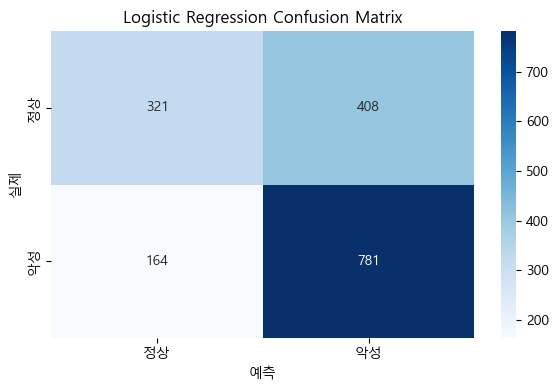


===== Linear SVM =====
Accuracy : 0.6458
Precision: 0.6670
Recall   : 0.7439
F1-score : 0.7034
              precision    recall  f1-score   support

          정상       0.61      0.52      0.56       729
          악성       0.67      0.74      0.70       945

    accuracy                           0.65      1674
   macro avg       0.64      0.63      0.63      1674
weighted avg       0.64      0.65      0.64      1674



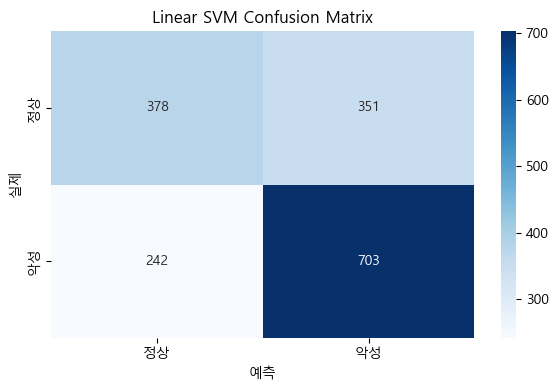

In [4]:
def evaluate_model(model, name):
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_valid_vec)

    print(f"\n===== {name} =====")
    print(f"Accuracy : {accuracy_score(y_valid, y_pred):.4f}")
    print(f"Precision: {precision_score(y_valid, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_valid, y_pred):.4f}")
    print(f"F1-score : {f1_score(y_valid, y_pred):.4f}")
    print(classification_report(y_valid, y_pred, target_names=["정상", "악성"]))

    # Confusion Matrix 시각화
    cm = confusion_matrix(y_valid, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["정상", "악성"],
                yticklabels=["정상", "악성"])
    plt.title(f"{name} Confusion Matrix")
    plt.ylabel("실제")
    plt.xlabel("예측")
    plt.tight_layout()
    plt.show()

# 로지스틱 회귀
evaluate_model(LogisticRegression(max_iter=1000), "Logistic Regression")

# 선형 SVM
evaluate_model(LinearSVC(max_iter=1000), "Linear SVM")

## 결과 요약

| 모델 | Accuracy | Precision | Recall | F1-score |
|------|----------|-----------|--------|----------|
| Logistic Regression | 0.6583 | 0.6569 | 0.8265 | 0.7320 |
| Linear SVM | 0.6458 | 0.6670 | 0.7439 | 0.7034 |

- 로지스틱 회귀가 F1-score 기준으로 더 우수한 성능을 보임
- 두 모델 모두 악성 댓글 Recall이 높아 악성 댓글 탐지에 유리한 경향
- 정상 댓글 Recall이 낮은 편으로, 정상 댓글을 악성으로 오분류하는 경향이 있음
- 이는 TF-IDF 기반 단순 모델의 한계로, 이후 BERT 파인튜닝을 통한 성능 개선 기대